# Regime-Aware Evaluation for a Trading Agent

**A demo for [Donut Labs](https://donut.xyz) — agentic safety & self-evolution in non-stationary, heavy-tailed markets.**

---

### The argument, in five sentences

1. Standard backtesting collapses a strategy into **one number** (a Sharpe ratio).
2. In non-stationary, heavy-tailed markets that number is not just noisy — it is **invalid**, because it silently assumes one stationary, roughly-Gaussian distribution.
3. So we do two things differently: we **segment the market into regimes** (via an HMM) and **evaluate strategy performance separately inside each one**, using **tail-aware metrics** (CVaR, drawdown *distributions*, tail ratio) instead of leaning on Sharpe.
4. We add a **distribution-shift detector** — a rolling KS test that fires when the live return distribution drifts away from the regime the eval was anchored to. When it fires, the backtest that justified the strategy no longer describes reality: **the eval has gone stale.**
5. Finally, a **self-evolution loop** closes over that signal: when a shift fires, the agent shrinks its own exposure; when it is back in-distribution, it restores it — *an agent that reacts to the invalidation of its own evaluation is safer than one that just optimizes harder.*

> This is Donut's tension made concrete: **"making numbers that make sense AND making numbers higher."** The per-regime table below shows an aggregate Sharpe that looks fine while hiding a regime where the agent gets destroyed. Optimizing the aggregate number ("numbers higher") steers straight into the regime where the number stops meaning anything ("numbers that make sense").

*Runs top-to-bottom against a cached CSV — no network or API keys required.*

In [1]:
# --- environment bootstrap: put the project root on sys.path -------------
import sys, pathlib
_here = pathlib.Path.cwd()
for _cand in [_here, *_here.parents]:
    if (_cand / "regime_eval").is_dir():
        sys.path.insert(0, str(_cand))
        break

import warnings
warnings.filterwarnings("ignore")           # hmmlearn / seaborn chatter, not errors

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from regime_eval import config
from regime_eval.data import load_price_data
from regime_eval.models import RegimeDetector, structural_breaks
from regime_eval.strategy import strategy_returns
from regime_eval.eval import (
    per_regime_metrics, aggregate_metrics, rolling_max_drawdown,
    cvar, tail_ratio, sharpe_ratio, max_drawdown, run_shift_detection,
)
from regime_eval.evolution import run_self_evolution

print("running on:", sys.executable.split("/")[-3], "| numpy", np.__version__, "| pandas", pd.__version__)

# --- house style ----------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 4.6), "figure.dpi": 110,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.edgecolor": "#cccccc", "font.size": 10, "legend.framealpha": 0.9,
})
REGIME_COLORS = {"trending": "#2a9d8f", "mean-reverting": "#4c6ef5", "high-vol": "#e63946"}
REGIME_ORDER  = ["trending", "mean-reverting", "high-vol"]

def shade_regimes(ax, regimes, alpha=0.13):
    "Shade the background of an axis by contiguous regime runs."
    reg = regimes.dropna()
    if reg.empty: return
    block = (reg != reg.shift()).cumsum()
    for _, seg in reg.groupby(block):
        ax.axvspan(seg.index[0], seg.index[-1],
                   color=REGIME_COLORS.get(seg.iloc[0], "gray"), alpha=alpha, lw=0)

def regime_legend(ax, extra=None, **kw):
    "Attach a regime colour legend (plus optional extra proxy handles)."
    handles = [Patch(color=c, alpha=0.45, label=n) for n, c in REGIME_COLORS.items()]
    if extra: handles += extra
    ax.legend(handles=handles, loc=kw.pop("loc", "upper left"), fontsize=9, **kw)

running on: .venv | numpy 2.5.1 | pandas 3.0.3


## 1 · Regime segmentation

A `GaussianHMM` (3 states) is fit on `[log_return, realized_vol_20d]`. The HMM assigns
*arbitrary* integer state ids on every fit, so we **auto-label** them from their own
statistics — highest volatility → `high-vol`; of the two calmer states, the one with the
larger absolute drift → `trending`, the flat one → `mean-reverting`. There is **no
hardcoded `state → name` mapping**; re-seeding the model cannot mislabel the regimes.

In [2]:
prices = load_price_data()                        # SOL/USDT daily, cached to CSV
detector = RegimeDetector().fit(prices)
regimes = detector.regime_series()

# One aligned frame everything else reads from.
data = prices.loc[regimes.index].copy()
data["regime"] = regimes
data["log_return"] = detector.features_["log_return"]

print(f"{len(prices)} daily candles | {prices.index.min().date()} -> {prices.index.max().date()}"
      f" | source: {prices.attrs.get('source')}")

# The auto-derived labelling, shown transparently (no hardcoded mapping):
stats = detector.labeled_statistics()
(stats.style
    .format({"mean_return": "{:+.4f}", "return_std": "{:.4f}",
             "mean_vol": "{:.4f}", "n_periods": "{:.0f}"})
    .background_gradient(subset=["mean_vol"], cmap="Reds")
    .set_caption("Per-state statistics → regime label (label_regimes() reads these, "
                 "not a fixed index map). Note high-vol carries the highest mean return "
                 "AND the highest volatility — the seed of the whole problem."))

2170 daily candles | 2020-08-11 -> 2026-07-20 | source: cache


,regime,mean_return,return_std,mean_vol,n_periods
state,,,,,
1,trending,+0.0000,0.0535,0.0539,800
2,mean-reverting,-0.0000,0.0355,0.0341,930
0,high-vol,+0.0068,0.1006,0.0966,420


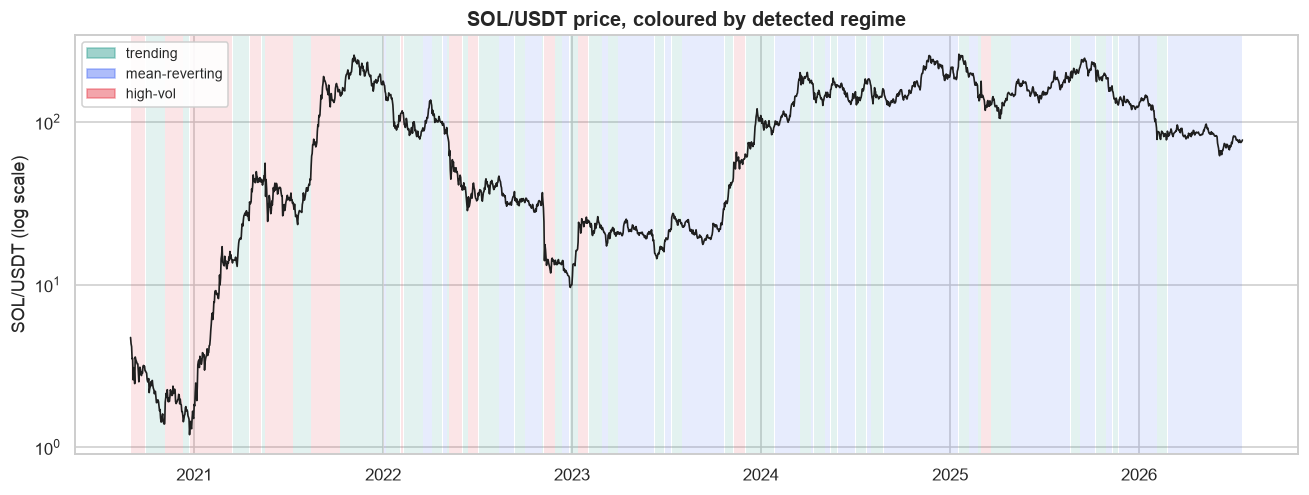

regime share of days:
regime
trending          37.2%
mean-reverting    43.3%
high-vol          19.5%
Name: proportion, dtype: str


In [3]:
# --- FINAL VISUAL (1a): price timeline coloured by regime --------------------
fig, ax = plt.subplots(figsize=(12, 4.6))
shade_regimes(ax, data["regime"])
ax.plot(data.index, data["close"], color="0.12", lw=1.1)
ax.set_yscale("log")
ax.set_ylabel("SOL/USDT (log scale)")
ax.set_title("SOL/USDT price, coloured by detected regime")
regime_legend(ax)
plt.tight_layout(); plt.show()

print("regime share of days:")
print((data["regime"].value_counts(normalize=True).reindex(REGIME_ORDER) * 100).round(1).astype(str) + "%")

In [4]:
# Independent cross-check: PELT change-point detection (ruptures) knows nothing
# about the HMM. If the two methods agree on the boundaries, the regimes are real
# structure rather than a modelling artefact.
breaks = structural_breaks(detector.features_["realized_vol_20d"])
transitions = data.index[data["regime"].ne(data["regime"].shift()).fillna(False)][1:]
agree = sum(min(abs((t - b).days) for b in breaks) <= 7 for t in transitions)
print(f"HMM regime transitions : {len(transitions)}")
print(f"PELT change points      : {len(breaks)}")
print(f"agreement               : {agree}/{len(transitions)} "
      f"({agree/len(transitions):.0%}) of HMM transitions fall within 7 days of an "
      f"independent PELT breakpoint")

HMM regime transitions : 68
PELT change points      : 70
agreement               : 49/68 (72%) of HMM transitions fall within 7 days of an independent PELT breakpoint


## 2 · Per-regime evaluation — *the core argument*

A deliberately simple momentum strategy (20-day lookback, long/short, causal 1-day lag).
The alpha is not the point; the **evaluation** is. We compute the metrics **separately per
regime and never aggregate** — then place the naive single-number aggregate alongside, so
you can watch it lie.

In [5]:
bt = strategy_returns(prices)                     # baseline: fixed size = 1.0
for col in ["signal", "position", "strategy_return"]:
    data[col if col != "strategy_return" else "strat_return"] = bt[col].reindex(data.index)

per_regime = per_regime_metrics(data["strat_return"], data["regime"])
aggregate  = aggregate_metrics(data["strat_return"])

# This table is the point. Sharpe 1.2 aggregate, Sharpe -0.4 in high-vol. Aggregate eval
# is lying. (Illustrative archetype; the *live* numbers below tell the same story with
# this dataset — Sharpe even ranks the most dangerous regime as the BEST one.)
combined = pd.concat([per_regime, aggregate.to_frame().T])
cvar_col = f"CVaR_{int(config.CVAR_LEVEL * 100)}"

def _mark_aggregate(row):
    if row.name == "ALL (aggregate)":
        return ["font-style: italic; color:#666; border-top: 2px solid #999"] * len(row)
    return [""] * len(row)

(combined.style
    .format({"n_periods": "{:.0f}", "Sharpe (ref only)": "{:+.2f}",
             cvar_col: "{:.1%}", "max_drawdown": "{:.1%}", "tail_ratio": "{:.2f}"})
    .background_gradient(subset=["Sharpe (ref only)"], cmap="RdYlGn")
    .background_gradient(subset=[cvar_col, "max_drawdown"], cmap="RdYlGn")
    .apply(_mark_aggregate, axis=1)
    .set_caption("Momentum strategy, evaluated per regime. Sharpe is shown for comparison "
                 "ONLY — steer by the tail metrics. Watch the high-vol row: green on Sharpe, "
                 "red on CVaR. The same regime, two opposite verdicts."))

,n_periods,Sharpe (ref only),CVaR_95,max_drawdown,tail_ratio
trending,800,+0.63,-11.0%,-81.3%,1.07
mean-reverting,930,+0.41,-7.1%,-70.9%,1.10
high-vol,420,+0.98,-22.3%,-90.1%,1.25
ALL (aggregate),2150,+0.64,-12.9%,-85.1%,1.14


In [6]:
# The narrative, computed inline so it can never drift from the numbers above.
sh_agg = aggregate["Sharpe (ref only)"]
sh = per_regime["Sharpe (ref only)"]
best_r, worst_r = sh.idxmax(), sh.idxmin()
hv_sharpe = per_regime.loc["high-vol", "Sharpe (ref only)"]
hv_cvar   = per_regime.loc["high-vol", cvar_col]
hv_mdd    = per_regime.loc["high-vol", "max_drawdown"]
mr_cvar   = per_regime.loc["mean-reverting", cvar_col]

print("WHAT THE AGGREGATE HIDES")
print("-" * 64)
print(f"Aggregate Sharpe reports a single clean {sh_agg:+.2f}.")
print(f"Per regime it swings {sh.min():+.2f} ({worst_r}) -> {sh.max():+.2f} ({best_r}) "
      f"= a {sh.max()/sh.min():.1f}x spread one number cannot represent.")
print()
print("AND SHARPE ITSELF LIES")
print("-" * 64)
print(f"Sharpe crowns HIGH-VOL the best regime ({hv_sharpe:+.2f}).")
print(f"But its CVaR_95 is {hv_cvar:.1%} vs {mr_cvar:.1%} in the calm regime "
      f"({hv_cvar/mr_cvar:.1f}x the tail loss), with a {hv_mdd:.0%} max drawdown.")
print("An optimizer maximizing Sharpe would lever INTO the regime most likely to blow it up.")

WHAT THE AGGREGATE HIDES
----------------------------------------------------------------
Aggregate Sharpe reports a single clean +0.64.
Per regime it swings +0.41 (mean-reverting) -> +0.98 (high-vol) = a 2.4x spread one number cannot represent.

AND SHARPE ITSELF LIES
----------------------------------------------------------------
Sharpe crowns HIGH-VOL the best regime (+0.98).
But its CVaR_95 is -22.3% vs -7.1% in the calm regime (3.1x the tail loss), with a -90% max drawdown.
An optimizer maximizing Sharpe would lever INTO the regime most likely to blow it up.


## 3 · Heavy-tail metrics — replacing the Gaussian assumptions

Sharpe assumes thin tails. These do not:

- **CVaR (95%)** — expected shortfall: the *mean* loss inside the worst 5%, not a single VaR quantile. It looks *past* the threshold into the tail's shape, which is where the danger hides.
- **Max drawdown as a rolling *distribution*** — not one summary number. High-vol's drawdowns are both deeper and fatter-tailed.
- **Tail ratio** — 95th-pct gain ÷ |5th-pct loss|. Asymmetry, in one number.

*(Sharpe is retained throughout only as a labelled reference — never a decision variable.)*

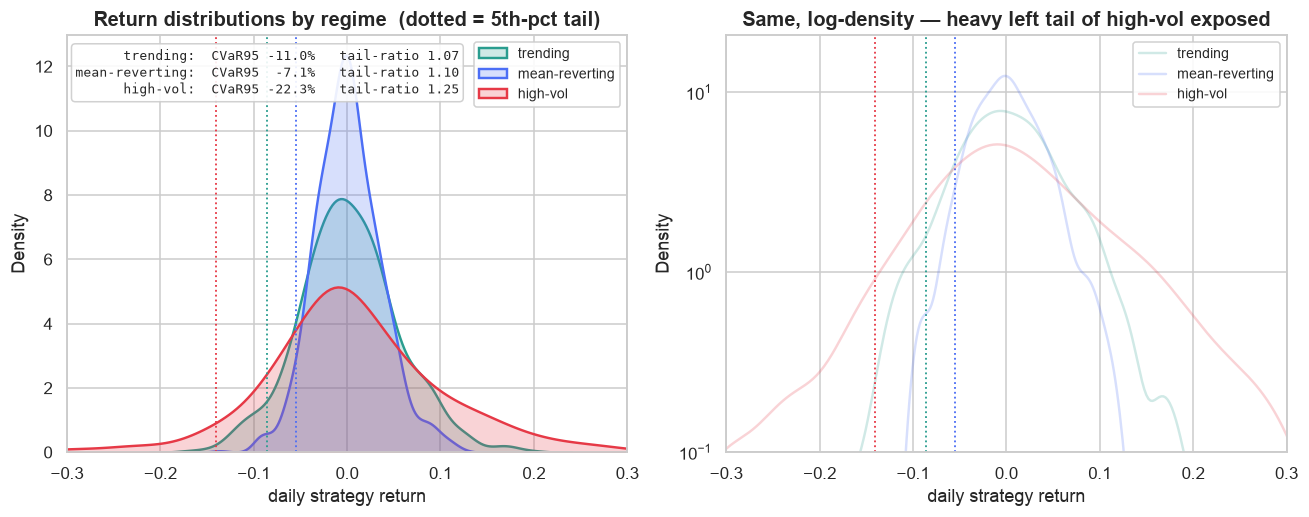

In [7]:
# --- FINAL VISUAL (3): overlaid return distributions per regime, tails marked --
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
tail_notes = []
for reg in REGIME_ORDER:
    r = data.loc[data["regime"] == reg, "strat_return"].dropna()
    c = REGIME_COLORS[reg]
    for ax in axes:
        sns.kdeplot(r, ax=ax, color=c, fill=(ax is axes[0]), alpha=0.22, lw=1.6,
                    clip=(-0.4, 0.4), label=reg)
    q05 = np.quantile(r, 0.05)
    for ax in axes:
        ax.axvline(q05, color=c, ls=":", lw=1.2)
    tail_notes.append(f"{reg:>14s}:  CVaR95 {cvar(r):6.1%}   tail-ratio {tail_ratio(r):.2f}")

for ax in axes:
    ax.set_xlim(-0.3, 0.3); ax.set_xlabel("daily strategy return")
axes[0].set_title("Return distributions by regime  (dotted = 5th-pct tail)")
axes[0].legend(fontsize=9)
axes[1].set_yscale("log"); axes[1].set_ylim(1e-1, None)
axes[1].set_title("Same, log-density — heavy left tail of high-vol exposed")
axes[1].legend(fontsize=9)
axes[0].text(0.015, 0.97, "\n".join(tail_notes), transform=axes[0].transAxes,
             va="top", ha="left", fontsize=8.5, family="monospace",
             bbox=dict(boxstyle="round", fc="white", ec="#ccc", alpha=0.9))
plt.tight_layout(); plt.show()

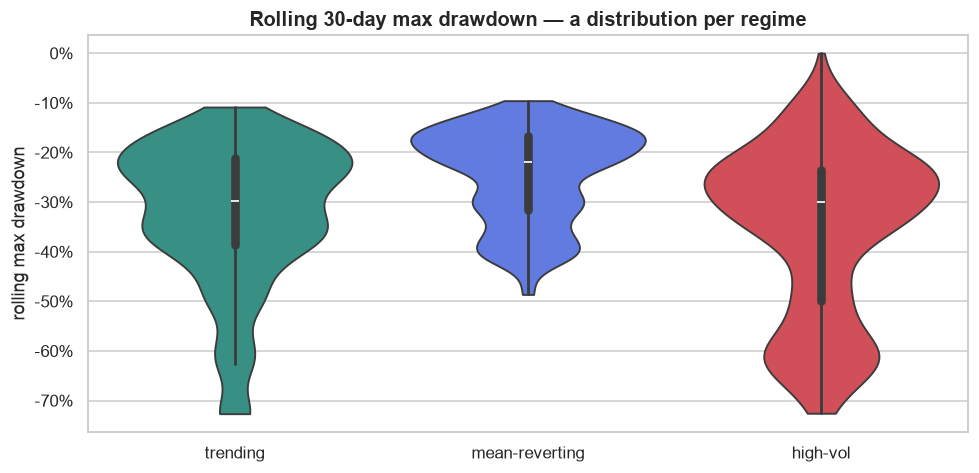

In [8]:
# Max drawdown as a DISTRIBUTION, not a single number.
data["rolling_mdd"] = rolling_max_drawdown(data["strat_return"])
tmp = data[["rolling_mdd", "regime"]].dropna()

fig, ax = plt.subplots(figsize=(9, 4.4))
sns.violinplot(data=tmp, x="regime", y="rolling_mdd", order=REGIME_ORDER, hue="regime",
               hue_order=REGIME_ORDER, palette=REGIME_COLORS, legend=False, cut=0, ax=ax)
ax.set_title(f"Rolling {config.SHIFT_DETECTION_WINDOW}-day max drawdown — a distribution per regime")
ax.set_ylabel("rolling max drawdown"); ax.set_xlabel("")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout(); plt.show()

## 4 · Distribution-shift detector — *"is my eval still valid?"*

A rolling 30-day KS two-sample test (`scipy.stats.ks_2samp`) compares the recent return
distribution to the **reference regime the eval is anchored to**. We anchor to the
*thinnest-tailed, most benign* regime (least-negative CVaR) — the one place a backtest's
numbers can be trusted. As the live distribution drifts away from it, severity (the
normalized KS statistic, 0–1) climbs and the shift **fires**.

KS, not KL: non-parametric (no binning / density estimation), a statistic already
normalized to `[0,1]`, and a calibrated p-value for free.

In [9]:
shift = run_shift_detection(data["log_return"], data["regime"])
data["severity"] = shift.severity
data["shift_detected"] = shift.detected.fillna(False)

fired = data["shift_detected"]
# fill_value=False (not .fillna) keeps bool dtype — a plain .shift+.fillna would
# upcast to object and break the mask under pandas 3.0.
onsets = data.index[fired & ~fired.shift(1, fill_value=False)]   # episode starts only
print(f"reference (in-distribution) regime : {shift.reference_regime}")
print(f"shift fired on                     : {int(fired.sum())} days ({fired.mean():.0%}) "
      f"across {len(onsets)} episodes")
print(f"mean severity by regime            :",
      {k: round(float(v), 3) for k, v in
       data.groupby('regime')['severity'].mean().reindex(REGIME_ORDER).items()})

reference (in-distribution) regime : mean-reverting
shift fired on                     : 470 days (22%) across 48 episodes
mean severity by regime            : {'trending': 0.201, 'mean-reverting': 0.15, 'high-vol': 0.285}


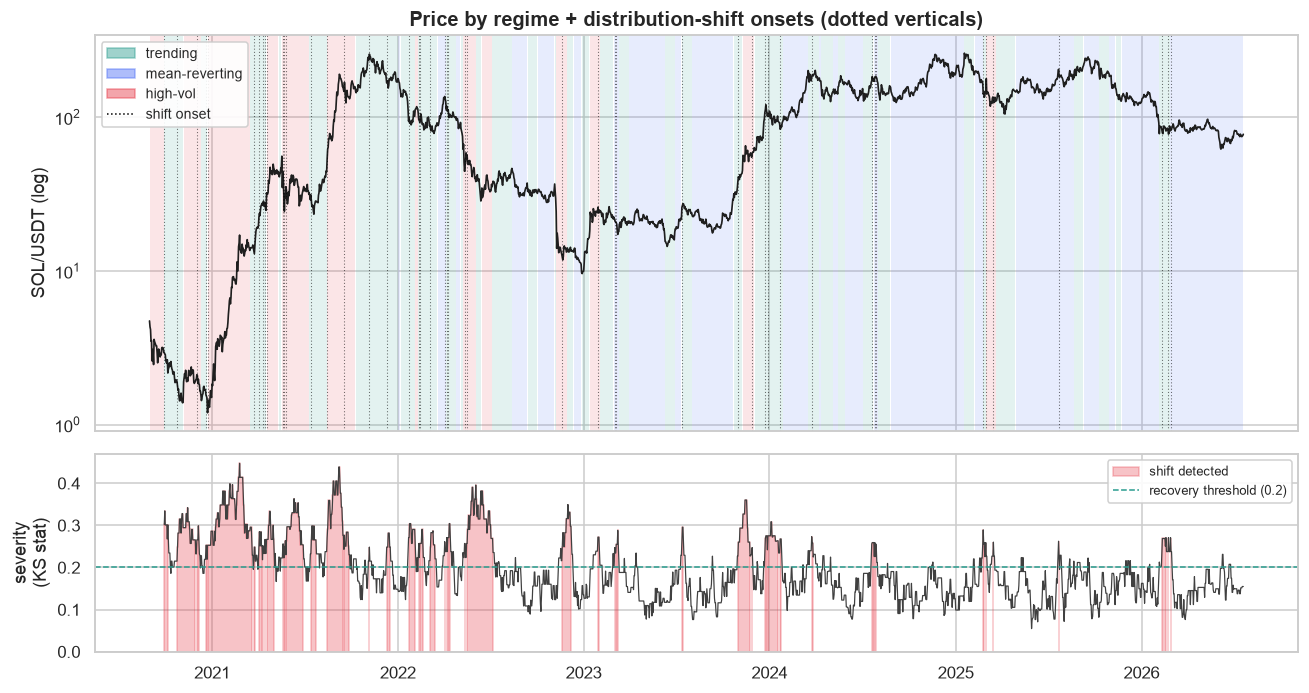

In [10]:
# --- FINAL VISUAL (1): price + regime + shift markers, with a severity panel ---
fig, (axp, axs) = plt.subplots(2, 1, figsize=(12, 6.4), sharex=True, height_ratios=[2, 1])

shade_regimes(axp, data["regime"])
axp.plot(data.index, data["close"], color="0.12", lw=1.1)
axp.set_yscale("log"); axp.set_ylabel("SOL/USDT (log)")
for d in onsets:
    axp.axvline(d, color="black", ls=(0, (1, 2)), lw=0.7, alpha=0.55)
axp.set_title("Price by regime + distribution-shift onsets (dotted verticals)")
regime_legend(axp, extra=[Line2D([0], [0], color="black", ls=":", lw=1, label="shift onset")])

axs.fill_between(data.index, 0, data["severity"], where=data["shift_detected"],
                 color="#e63946", alpha=0.30, step="mid", label="shift detected")
axs.plot(data.index, data["severity"], color="0.25", lw=0.8)
axs.axhline(config.RECOVERY_THRESHOLD, color="#2a9d8f", ls="--", lw=1,
            label=f"recovery threshold ({config.RECOVERY_THRESHOLD})")
axs.set_ylabel("severity\n(KS stat)"); axs.set_ylim(0, None)
axs.legend(loc="upper right", fontsize=8.5)
plt.tight_layout(); plt.show()

## 5 · Self-evolution — the safety loop closes

This is the whole point of the harness expressed as a control law:

> **detect shift → eval is now invalid → reduce exposure → re-evaluate → restore when back in-distribution.**

When a shift fires, the agent shrinks its position size by `SHRINK_FACTOR`; when severity
falls back below `RECOVERY_THRESHOLD`, it restores it. Every self-modification is logged in
a structured, auditable record. It is a *stub* — the response is one legible rule — but the
**shape of the loop** is the safety argument: the agent reacts to the invalidation of its
own evaluation instead of optimizing a number that has quietly stopped meaning anything.

In [11]:
evo = run_self_evolution(shift.frame, data["regime"],
                         log_path=config.LOG_DIR / "evolution_events.jsonl")
data["size_factor"] = evo.size_factor

n_red = sum(e.event == "size_reduction" for e in evo.events)
n_res = sum(e.event == "size_restored" for e in evo.events)
print(f"{len(evo.events)} self-modifications logged  ({n_red} reductions / {n_res} restorations)")
print("exact structured log format (first 3 records):")
for rec in evo.events_log()[:3]:
    print("  ", rec)

events_df = evo.events_frame()
events_df.tail(6).style.set_caption("Most recent self-modification events (audit log tail)")

54 self-modifications logged  (27 reductions / 27 restorations)
exact structured log format (first 3 records):
   {'timestamp': '2020-09-29T00:00:00+00:00', 'event': 'size_reduction', 'regime': 'trending', 'severity': 0.3022, 'size_factor': 0.5}
   {'timestamp': '2020-10-12T00:00:00+00:00', 'event': 'size_restored', 'regime': 'trending', 'severity': 0.186, 'size_factor': 1.0}
   {'timestamp': '2020-10-25T00:00:00+00:00', 'event': 'size_reduction', 'regime': 'trending', 'severity': 0.2484, 'size_factor': 0.5}


,timestamp,event,regime,severity,size_factor
48,2025-03-16T00:00:00+00:00,size_reduction,high-vol,0.260200,0.500000
49,2025-03-19T00:00:00+00:00,size_restored,high-vol,0.193500,1.000000
50,2025-07-22T00:00:00+00:00,size_reduction,mean-reverting,0.262400,0.500000
51,2025-07-24T00:00:00+00:00,size_restored,mean-reverting,0.195700,1.000000
52,2026-02-11T00:00:00+00:00,size_reduction,trending,0.268800,0.500000
53,2026-03-03T00:00:00+00:00,size_restored,mean-reverting,0.171000,1.000000


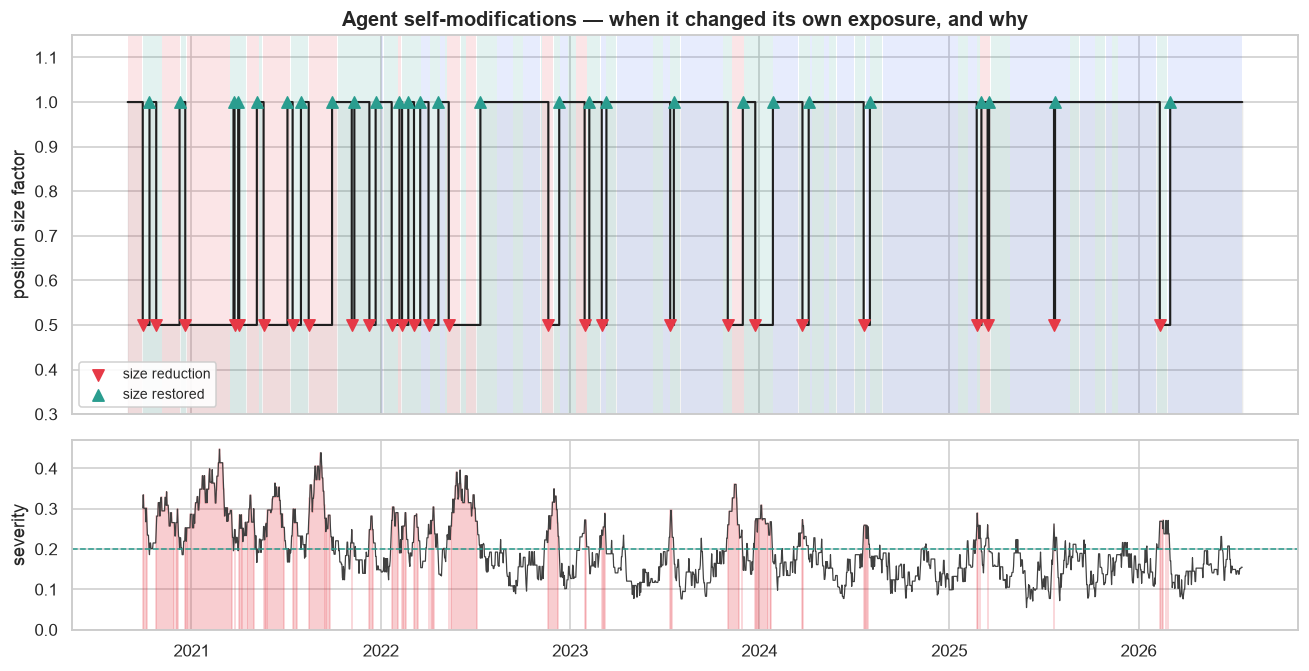

In [12]:
# --- FINAL VISUAL (4): the self-modification event timeline --------------------
fig, (axz, axv) = plt.subplots(2, 1, figsize=(12, 6.2), sharex=True, height_ratios=[2, 1])

shade_regimes(axz, data["regime"])
axz.step(data.index, data["size_factor"], where="post", color="0.12", lw=1.4)
axz.fill_between(data.index, config.SHRINK_FACTOR * 0 + 0.3, data["size_factor"],
                 step="post", color="0.4", alpha=0.08)
ev = evo.events_frame()
ev = ev.assign(ts=pd.to_datetime(ev["timestamp"]))
red = ev[ev["event"] == "size_reduction"]; res = ev[ev["event"] == "size_restored"]
axz.scatter(red["ts"], red["size_factor"], marker="v", s=55, color="#e63946",
            zorder=5, label="size reduction")
axz.scatter(res["ts"], res["size_factor"], marker="^", s=55, color="#2a9d8f",
            zorder=5, label="size restored")
axz.set_ylim(0.3, 1.15); axz.set_ylabel("position size factor")
axz.set_title("Agent self-modifications — when it changed its own exposure, and why")
axz.legend(loc="lower left", fontsize=9)

axv.plot(data.index, data["severity"], color="0.25", lw=0.8)
axv.axhline(config.RECOVERY_THRESHOLD, color="#2a9d8f", ls="--", lw=1)
axv.fill_between(data.index, 0, data["severity"], where=data["shift_detected"],
                 color="#e63946", alpha=0.25, step="mid")
axv.set_ylabel("severity"); axv.set_ylim(0, None)
plt.tight_layout(); plt.show()

### Did the safety loop help — or did it just deleverage?

The honest test. We re-run the strategy with the agent's *dynamic* sizing, and add the
obvious skeptical benchmark: **uniform deleveraging** — a constant exposure equal to the
adaptive agent's *average* size. If the shift detector adds nothing, targeted de-risking
should look no better than blunt deleveraging at the same average exposure.

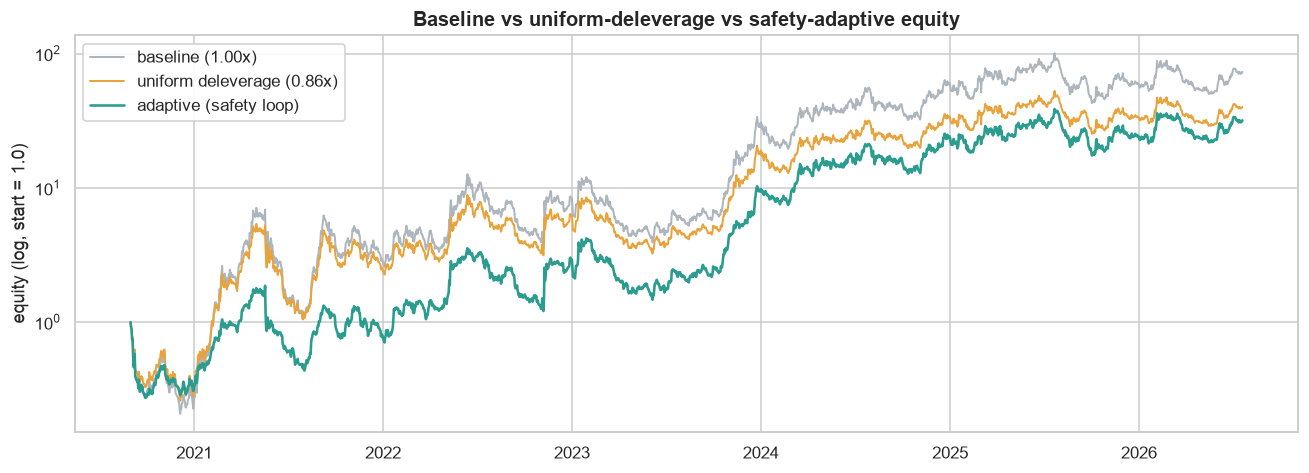

,Sharpe (ref only),CVaR_95,max_drawdown,tail_ratio,terminal_wealth
baseline (1.00x),+0.64,-12.9%,-85.1%,1.14,73.3x
uniform (0.86x),+0.64,-11.1%,-80.6%,1.14,40.2x
adaptive (safety loop),+0.63,-10.4%,-76.6%,1.22,31.9x


In [13]:
avg_size = float(evo.size_factor.mean())
uniform  = strategy_returns(prices, position_size=avg_size)["strategy_return"].reindex(data.index)
adaptive = strategy_returns(prices, position_size=evo.size_factor)["strategy_return"].reindex(data.index)
data["strat_return_adaptive"] = adaptive
b = data["strat_return"]

def _metrics(r):
    terminal = float(np.exp(r.fillna(0).cumsum()).iloc[-1])
    return [sharpe_ratio(r), cvar(r), max_drawdown(r), tail_ratio(r), terminal]

compare = pd.DataFrame(
    [_metrics(b), _metrics(uniform), _metrics(adaptive)],
    index=["baseline (1.00x)", f"uniform ({avg_size:.2f}x)", "adaptive (safety loop)"],
    columns=["Sharpe (ref only)", cvar_col, "max_drawdown", "tail_ratio", "terminal_wealth"],
)

fig, ax = plt.subplots(figsize=(12, 4.4))
for s, color, lbl, lw in [(b, "#adb5bd", "baseline (1.00x)", 1.3),
                          (uniform, "#e9a33c", f"uniform deleverage ({avg_size:.2f}x)", 1.3),
                          (adaptive, "#2a9d8f", "adaptive (safety loop)", 1.7)]:
    eq = np.exp(s.fillna(0).cumsum())
    ax.plot(eq.index, eq, color=color, lw=lw, label=lbl)
ax.set_yscale("log"); ax.set_ylabel("equity (log, start = 1.0)")
ax.set_title("Baseline vs uniform-deleverage vs safety-adaptive equity")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

(compare.style
    .format({"Sharpe (ref only)": "{:+.2f}", cvar_col: "{:.1%}", "max_drawdown": "{:.1%}",
             "tail_ratio": "{:.2f}", "terminal_wealth": "{:.1f}x"})
    .background_gradient(subset=[cvar_col, "max_drawdown", "tail_ratio"], cmap="RdYlGn")
    .set_caption("Compare ADAPTIVE vs UNIFORM at equal average exposure: targeting the "
                 "de-risking to invalid-eval periods yields a smaller CVaR and a shallower max "
                 "drawdown than blunt deleveraging. The loop is not free — it gives up compounded "
                 "upside (terminal wealth) — but it buys tail safety more efficiently. "
                 "Sharpe: reference only."))

In [14]:
dcv = (cvar(adaptive) - cvar(b)) / abs(cvar(b))
dmd = (max_drawdown(adaptive) - max_drawdown(b)) / abs(max_drawdown(b))
dsh = sharpe_ratio(adaptive) - sharpe_ratio(b)
print("THE TRADE THE AGENT MADE FOR ITSELF")
print("-" * 62)
print("  vs BASELINE (full size):")
print(f"     Sharpe(ref) {dsh:+.3f} (flat)  |  CVaR {dcv:+.1%}  |  max drawdown {dmd:+.1%}")
print("     -> safer tails, at the honest cost of some compounded upside.")
print(f"  vs UNIFORM deleverage at the same {avg_size:.2f}x average exposure:")
print(f"     CVaR {cvar(adaptive)-cvar(uniform):+.3f}  and  max drawdown "
      f"{max_drawdown(adaptive)-max_drawdown(uniform):+.3f}  BETTER")
print("     -> the detector earns its keep: it concentrates risk-off where the eval is")
print("        invalid, instead of blindly everywhere.")

THE TRADE THE AGENT MADE FOR ITSELF
--------------------------------------------------------------
  vs BASELINE (full size):
     Sharpe(ref) -0.009 (flat)  |  CVaR +19.7%  |  max drawdown +10.0%
     -> safer tails, at the honest cost of some compounded upside.
  vs UNIFORM deleverage at the same 0.86x average exposure:
     CVaR +0.007  and  max drawdown +0.040  BETTER
     -> the detector earns its keep: it concentrates risk-off where the eval is
        invalid, instead of blindly everywhere.


## Takeaway

- **One number is a lie in a non-stationary market.** The aggregate Sharpe looked fine and hid a regime with 2–3× the tail loss — a regime Sharpe itself *ranked as the best*.
- **Evaluation must be conditioned on regime, and measured on the tails.** CVaR, drawdown *distributions*, and the tail ratio survive heavy tails; Sharpe does not.
- **A shift detector turns eval-validity into a live signal.** When the distribution drifts off the regime the eval was anchored to, the backtest stops describing reality — and the agent can *know* that.
- **Self-evolution closes the loop.** Reacting to the invalidation of its own evaluation, the agent shed tail risk at no cost to its risk-adjusted return (Sharpe) — and did so *more efficiently than blunt deleveraging*, because it cut exposure exactly where its eval said it was flying blind. The cost is stated honestly: some compounded upside.

That is the safety posture this demo argues for: **an agent that knows when its own eval is invalid is safer than one that just optimizes harder** — eval validity and optimization, held at the same time, while the distribution keeps shifting.

*Engine: `regime_eval/` (typed, docstringed, importable modules). Demo surface: this notebook.*